In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import json
import os

df = pd.read_csv('../data/tarkwa_nasa_monthly.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Columns in file:", df.columns.tolist())

# Engineer the 5 additional features (cyclical month encoding + rainfall lags/rolling mean)
df['month_num'] = df['date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
df['rainfall_lag1'] = df['rainfall_mm'].shift(1)
df['rainfall_lag2'] = df['rainfall_mm'].shift(2)
df['rainfall_roll3'] = df['rainfall_mm'].shift(1).rolling(3).mean()

# Drop the first 3 rows (NaNs from lag/rolling features)
df = df.dropna().reset_index(drop=True)

EXOG_COLS = ['temp_mean_C','temp_max_C','temp_min_C','humidity_pct','pressure_kPa',
             'wind_speed_ms','month_sin','month_cos','rainfall_lag1','rainfall_lag2','rainfall_roll3']

print(f"\nDataset shape after feature engineering: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(df[['date', 'rainfall_mm'] + EXOG_COLS].head())

Columns in file: ['year', 'month', 'rainfall_mm', 'temp_mean_C', 'temp_max_C', 'temp_min_C', 'humidity_pct', 'pressure_kPa', 'wind_speed_ms', 'month_name', 'date']

Dataset shape after feature engineering: (435, 17)
Date range: 1990-04-01 00:00:00 to 2026-06-01 00:00:00
        date  rainfall_mm  temp_mean_C  temp_max_C  temp_min_C  humidity_pct  \
0 1990-04-01       251.53    26.527333   30.549000   23.508667     86.065333   
1 1990-05-01       187.32    25.471613   28.980000   22.756129     90.063226   
2 1990-06-01       199.58    24.828000   28.348000   22.210667     90.038000   
3 1990-07-01       104.21    23.691613   27.860000   20.665806     88.153871   
4 1990-08-01        33.37    24.405161   29.565806   20.812903     81.806774   

   pressure_kPa  wind_speed_ms     month_sin  month_cos  rainfall_lag1  \
0     99.836667       1.134000  8.660254e-01  -0.500000          70.49   
1    100.010323       1.042258  5.000000e-01  -0.866025         251.53   
2    100.163667       1.15

In [3]:
split_date = '2019-01-01'

train_df = df[df['date'] < split_date].reset_index(drop=True)
test_df  = df[df['date'] >= split_date].reset_index(drop=True)

y_train = train_df['rainfall_mm'].values
y_test  = test_df['rainfall_mm'].values
X_train = train_df[EXOG_COLS].values
X_test  = test_df[EXOG_COLS].values

train_dates = train_df['date']
test_dates  = test_df['date']

print(f"Training months: {len(y_train)} (Jan 1990 – Dec 2018)")
print(f"Test months:     {len(y_test)}  (Jan 2019 – Jun 2026)")

Training months: 345 (Jan 1990 – Dec 2018)
Test months:     90  (Jan 2019 – Jun 2026)


In [4]:
print("Running auto_arima with exogenous variables...")
print("This may take a few minutes...\n")

auto_model = auto_arima(
    y_train, X=X_train,
    seasonal=True,
    m=12,
    d=None, D=None,
    stepwise=True,
    information_criterion='aic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1,
)

print(f"\nBest order:          {auto_model.order}")
print(f"Best seasonal order: {auto_model.seasonal_order}")
print(f"AIC: {auto_model.aic():.2f}")

Running auto_arima with exogenous variables...
This may take a few minutes...

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=2.29 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3673.381, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3647.864, Time=1.38 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3654.808, Time=1.52 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3671.381, Time=0.19 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3668.527, Time=0.35 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=3639.314, Time=3.01 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.97 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=2.21 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=3648.002, Time=2.64 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=3641.220, Time=3.46 sec
 ARIMA(1,0,1)(2,0,0)[12] intercept   : AIC=3642.178, Time=3.16 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=3640.706, Time=2.65 sec
 ARIMA(2,0,1)(2,0,0)[1

In [5]:
p, d, q = auto_model.order
P, D, Q, m = auto_model.seasonal_order

print(f"Fitting SARIMAX({p},{d},{q})({P},{D},{Q})[{m}] with exogenous vars on full training set...")

sarimax_model = SARIMAX(
    y_train, exog=X_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

Fitting SARIMAX(1,0,0)(2,0,0)[12] with exogenous vars on full training set...
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  345
Model:             SARIMAX(1, 0, 0)x(2, 0, 0, 12)   Log Likelihood               -1673.383
Date:                            Tue, 21 Jul 2026   AIC                           3376.765
Time:                                    18:56:13   BIC                           3433.290
Sample:                                         0   HQIC                          3399.337
                                            - 345                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -170.3361     67.158    

In [6]:
print("Running walk-forward validation on test set...")

history_y = list(y_train)
history_X = list(X_train)
predictions = []

for i in range(len(y_test)):
    model = SARIMAX(
        history_y, exog=np.array(history_X),
        order=(p, d, q),
        seasonal_order=(P, D, Q, m),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    yhat = fit.forecast(steps=1, exog=X_test[i].reshape(1, -1))[0]
    yhat = max(0, yhat)
    predictions.append(yhat)

    history_y.append(y_test[i])
    history_X.append(X_test[i])
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(y_test)} steps")

predictions = np.array(predictions)
print("Walk-forward validation complete.")

Running walk-forward validation on test set...
  Completed 10/90 steps
  Completed 20/90 steps
  Completed 30/90 steps
  Completed 40/90 steps
  Completed 50/90 steps
  Completed 60/90 steps
  Completed 70/90 steps
  Completed 80/90 steps
  Completed 90/90 steps
Walk-forward validation complete.


In [7]:
mae  = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)

mask = y_test > 0
mape = np.mean(np.abs((y_test[mask] - predictions[mask]) / y_test[mask])) * 100

print("=== SARIMAX (Multivariate) — Test Set Performance ===")
print(f"MAE  : {mae:.2f} mm")
print(f"RMSE : {rmse:.2f} mm")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (non-zero months only)")

=== SARIMAX (Multivariate) — Test Set Performance ===
MAE  : 52.83 mm
RMSE : 73.43 mm
R²   : 0.6134
MAPE : 36.68%  (non-zero months only)


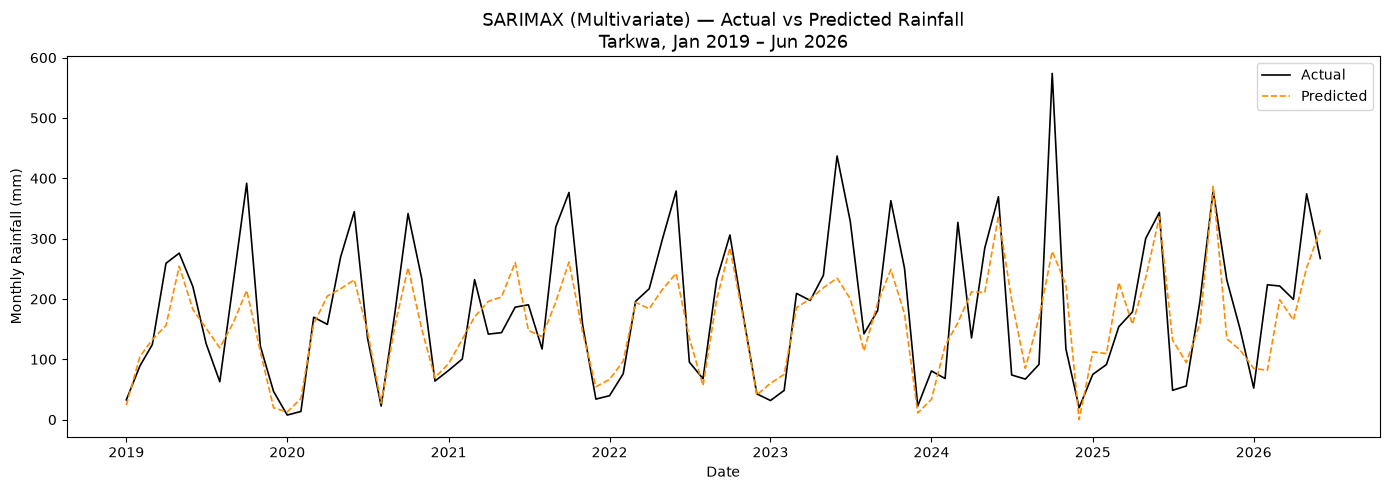

Plot saved.


In [8]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates.values, y_test,       label='Actual',    color='black', linewidth=1.2)
plt.plot(test_dates.values, predictions,  label='Predicted', color='darkorange',
         linewidth=1.2, linestyle='--')
plt.title('SARIMAX (Multivariate) — Actual vs Predicted Rainfall\nTarkwa, Jan 2019 – Jun 2026',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Monthly Rainfall (mm)')
plt.legend()
plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/sarimax_multi_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved.")

In [9]:
joblib.dump({
    'model_fit': sarimax_fit,
    'order': (p, d, q),
    'seasonal_order': (P, D, Q, m),
    'exog_cols': EXOG_COLS,
    'model_type': 'SARIMAX_multivariate',
}, '../models/sarimax_multi_model.pkl')

results = {
    'model': 'SARIMAX',
    'mode': 'multivariate',
    'mae': round(mae, 2),
    'rmse': round(rmse, 2),
    'r2': round(r2, 4),
    'mape': round(mape, 2),
    'order': f"({p},{d},{q})({P},{D},{Q})[{m}]",
}
with open('../models/sarimax_multi_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Model saved to models/sarimax_multi_model.pkl")
print("Results saved to models/sarimax_multi_results.json")
print(f"\nSummary: SARIMAX{results['order']}")
print(f"  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")

Model saved to models/sarimax_multi_model.pkl
Results saved to models/sarimax_multi_results.json

Summary: SARIMAX(1,0,0)(2,0,0)[12]
  MAE=52.83  RMSE=73.43  R²=0.6134  MAPE=36.68%
